##Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.src.legacy.preprocessing.image import ImageDataGenerator


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
dataset_path = path

##Pré-processamento

###Redimensionamento

In [4]:
IMG_SIZE = (128,128)

###Normalização

In [5]:
rescale=1./255

###Data Augmentation

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

###Validação e Teste

In [7]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

###Criação dos Conjuntos

In [44]:
train_generator = train_datagen.flow_from_directory(
    dataset_path + "/chest_xray/train",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    dataset_path + "/chest_xray/val",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    dataset_path + "/chest_xray/test",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


##Visualização das Imagens

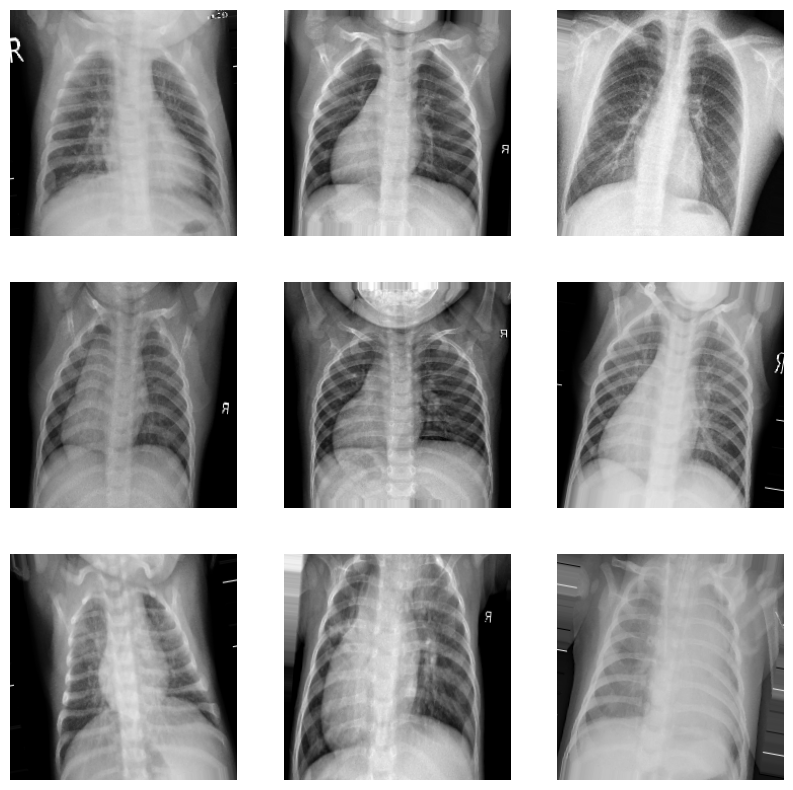

In [9]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

###Verificação do Balanceamento

In [10]:
import os

normal = len(os.listdir(dataset_path + "/chest_xray/train/NORMAL"))
pneumonia = len(os.listdir(dataset_path + "/chest_xray/train/PNEUMONIA"))

print("Normal:", normal)
print("Pneumonia:", pneumonia)

Normal: 1341
Pneumonia: 3875


In [11]:
total = normal + pneumonia

print(f"Normal: {normal/total:.2%}")
print(f"Pneumonia: {pneumonia/total:.2%}")

Normal: 25.71%
Pneumonia: 74.29%


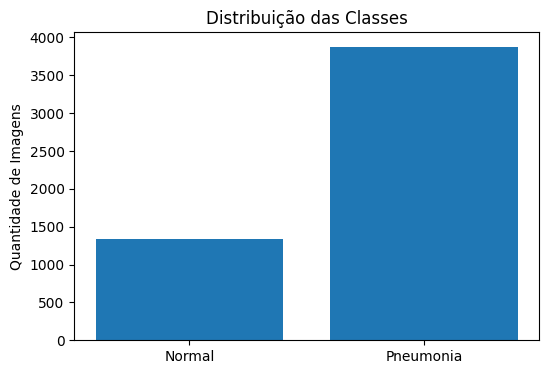

In [12]:
import matplotlib.pyplot as plt

classes = ['Normal', 'Pneumonia']
quantidades = [1341, 3875]

plt.figure(figsize=(6,4))
plt.bar(classes, quantidades)
plt.title('Distribuição das Classes')
plt.ylabel('Quantidade de Imagens')
plt.show()

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


##CNN Simples

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *

cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu',
           input_shape=(IMG_SIZE[0],IMG_SIZE[1],3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

###Compilação

In [15]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###Treinamento

In [16]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 691s 4s/step - accuracy: 0.8027 - loss: 0.4307 - val_accuracy: 0.8125 - val_loss: 0.5531
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 776s 4s/step - accuracy: 0.9043 - loss: 0.2474 - val_accuracy: 0.8125 - val_loss: 0.3714
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 669s 4s/step - accuracy: 0.9122 - loss: 0.2245 - val_accuracy: 0.7500 - val_loss: 0.4184
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 668s 4s/step - accuracy: 0.9193 - loss: 0.2042 - val_accuracy: 0.8750 - val_loss: 0.3634
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 668s 4s/step - accuracy: 0.9327 - loss: 0.1806 - val_accuracy: 0.7500 - val_loss: 0.3798


###Predições

In [35]:
y_pred = cnn_model.predict(test_generator)

y_pred = (y_pred > 0.5).astype(int)

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step


###Métricas

In [36]:
from sklearn.metrics import *

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            'Normal',
            'Pneumonia'
        ]
    )
)

              precision    recall  f1-score   support

      Normal       0.90      0.71      0.79       234
   Pneumonia       0.85      0.95      0.90       390

    accuracy                           0.86       624
   macro avg       0.87      0.83      0.85       624
weighted avg       0.87      0.86      0.86       624



###Matriz de Confusão

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[166  68]
 [ 18 372]]


###Heatmap

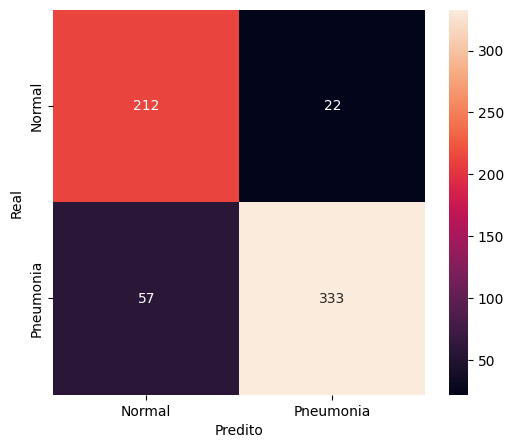

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal','Pneumonia'],
    yticklabels=['Normal','Pneumonia']
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

##Transfer Learning (MobileNetV2)



In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

In [48]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

###Modelo

In [49]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

x = Dropout(0.5)(x)

output = Dense(
    1,
    activation='sigmoid'
)(x)

mobilenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

###Compilação

In [51]:
mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###Treinamento

In [52]:
history_transfer = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 152s 890ms/step - accuracy: 0.8896 - loss: 0.2546 - val_accuracy: 0.9375 - val_loss: 0.1098
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 137s 837ms/step - accuracy: 0.9247 - loss: 0.1808 - val_accuracy: 1.0000 - val_loss: 0.1265
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 151s 895ms/step - accuracy: 0.9363 - loss: 0.1658 - val_accuracy: 0.9375 - val_loss: 0.1800
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.9383 - loss: 0.1591 - val_accuracy: 0.8125 - val_loss: 0.2361
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 142s 867ms/step - accuracy: 0.9410 - loss: 0.1498 - val_accuracy: 0.9375 - val_loss: 0.1585


###Predições

In [53]:
y_pred = mobilenet_model.predict(test_generator)

y_pred = (y_pred > 0.5).astype(int)

y_true = test_generator.classes

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 696ms/step


###Matriz de Confusão

In [54]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[212  22]
 [ 57 333]]


###HeatMap

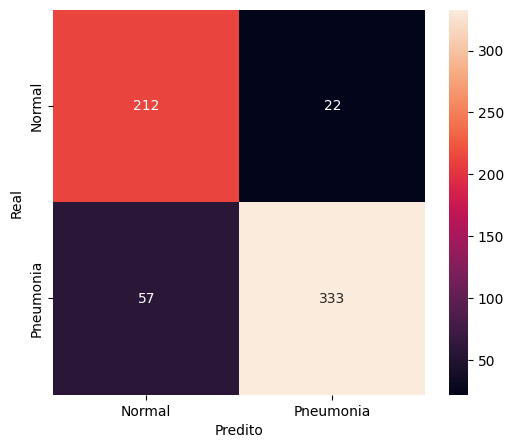

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Normal','Pneumonia'],
    yticklabels=['Normal','Pneumonia']
)

plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

###Comparação

###Função para avaliação

In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(model, test_generator):

    y_true = test_generator.classes

    y_prob = model.predict(test_generator)

    y_pred = (y_prob > 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(y_true, y_pred)

    recall = recall_score(y_true, y_pred)

    f1 = f1_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cm': cm
    }

###Avaliação de ambos

In [64]:
cnn_results = evaluate_model(
    cnn_model,
    test_generator
)

mobile_results = evaluate_model(
    mobilenet_model,
    test_generator
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 502ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 594ms/step


###Tabela comparativa

In [65]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['CNN', 'MobileNet'],
    'Accuracy': [
        cnn_results['accuracy'],
        mobile_results['accuracy']
    ],
    'Precision': [
        cnn_results['precision'],
        mobile_results['precision']
    ],
    'Recall': [
        cnn_results['recall'],
        mobile_results['recall']
    ],
    'F1 Score': [
        cnn_results['f1'],
        mobile_results['f1']
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN,0.623397,0.624398,0.997436,0.768016
1,MobileNet,0.873397,0.938028,0.853846,0.893960


###Curvas de treinamento

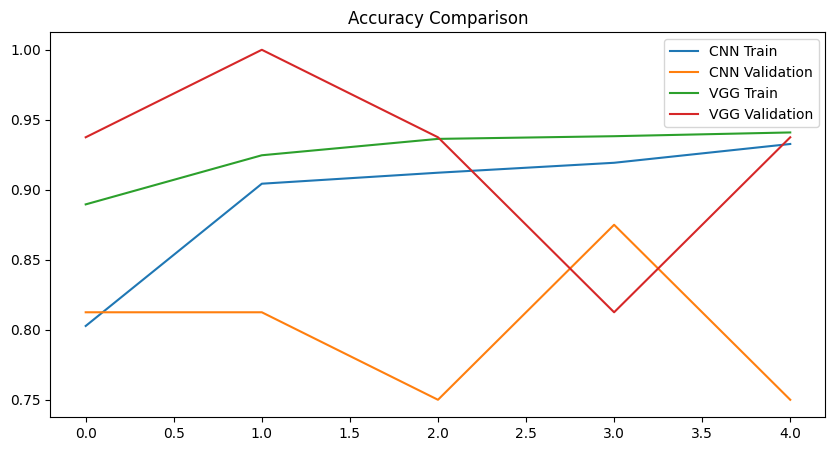

In [66]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='CNN Train'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN Validation'
)

plt.plot(
    history_transfer.history['accuracy'],
    label='VGG Train'
)

plt.plot(
    history_transfer.history['val_accuracy'],
    label='VGG Validation'
)

plt.legend()
plt.title('Accuracy Comparison')
plt.show()

###Loss

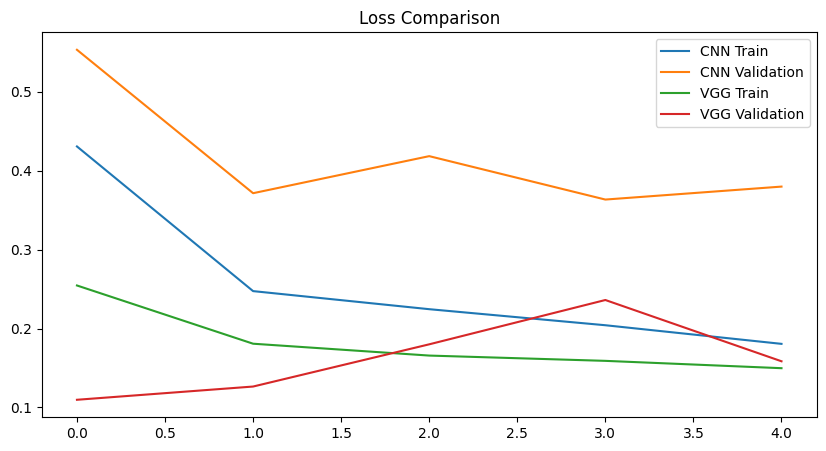

In [67]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['loss'],
    label='CNN Train'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='CNN Validation'
)

plt.plot(
    history_transfer.history['loss'],
    label='VGG Train'
)

plt.plot(
    history_transfer.history['val_loss'],
    label='VGG Validation'
)

plt.legend()
plt.title('Loss Comparison')
plt.show()

##Interface do Assistente Cardiológico

###Predição

In [76]:
arquivo_normal = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/NORMAL/IM-0001-0001.jpeg'
arquivo_pneumonia = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person100_bacteria_480.jpeg'

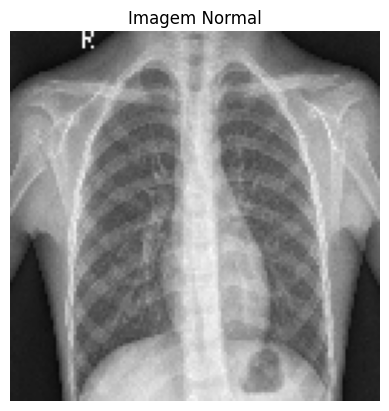

In [91]:

from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_to_plot = image.load_img(arquivo_normal, target_size=(128,128))
plt.imshow(img_to_plot)
plt.title('Imagem Normal')
plt.axis('off')
plt.show()

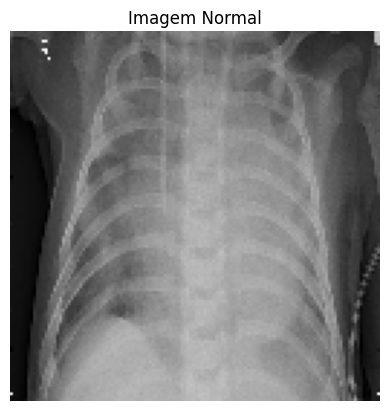

In [92]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_to_plot = image.load_img(arquivo_pneumonia, target_size=(128,128))
plt.imshow(img_to_plot)
plt.title('Imagem Normal')
plt.axis('off')
plt.show()

###Predição Normal

In [84]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    arquivo_normal,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

pred = mobilenet_model.predict(img_array)

if pred[0][0] > 0.5:
    print("Resultado: Pneumonia")
else:
    print("Resultado: Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Resultado: Normal


###Predição Pnmeumonia

In [85]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    arquivo_pneumonia,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

pred = mobilenet_model.predict(img_array)

if pred[0][0] > 0.5:
    print("Resultado: Pneumonia")
else:
    print("Resultado: Normal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Resultado: Pneumonia


##Salvando os modelos

In [82]:
mobilenet_model.save("mobilenet_pneumonia.keras")

In [83]:
cnn_model.save("cnn_pneumonia.keras")